In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    TimeDistributed, Conv2D, MaxPooling2D,
    Flatten, LSTM, Dense, Dropout
)

2026-04-03 20:37:55.523619: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775248675.705325      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775248675.752946      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775248676.181125      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775248676.181175      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775248676.181179      55 computation_placer.cc:177] computation placer alr

In [2]:
import os

# المسار الرئيسي للداتا
DATASET_PATH = "/kaggle/input/datasets/venkatkumar001/human-activity-recognition-ucf50-video-dataset"

IMG_SIZE = 48      # حجم كل frame
SEQ_LEN = 20       # عدد frames لكل فيديو
EPOCHS = 20
BATCH_SIZE = 8
# الفئات الحقيقية جوه فولدر UCF50
classes_path = os.path.join(DATASET_PATH, "UCF50")

# أول 5 فئات فقط (تقدير سريع للتدريب)
selected_classes = sorted(os.listdir(classes_path))[:45]
print("Selected classes:", selected_classes)

# map للفئات
label_map = {cls: idx for idx, cls in enumerate(selected_classes)}

Selected classes: ['BaseballPitch', 'Basketball', 'BenchPress', 'Biking', 'Billiards', 'BreastStroke', 'CleanAndJerk', 'Diving', 'Drumming', 'Fencing', 'GolfSwing', 'HighJump', 'HorseRace', 'HorseRiding', 'HulaHoop', 'JavelinThrow', 'JugglingBalls', 'JumpRope', 'JumpingJack', 'Kayaking', 'Lunges', 'MilitaryParade', 'Mixing', 'Nunchucks', 'PizzaTossing', 'PlayingGuitar', 'PlayingPiano', 'PlayingTabla', 'PlayingViolin', 'PoleVault', 'PommelHorse', 'PullUps', 'Punch', 'PushUps', 'RockClimbingIndoor', 'RopeClimbing', 'Rowing', 'SalsaSpin', 'SkateBoarding', 'Skiing', 'Skijet', 'SoccerJuggling', 'Swing', 'TaiChi', 'TennisSwing']


In [3]:
def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // SEQ_LEN, 1)

    for i in range(SEQ_LEN):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()

        if not ret:
            frame = np.zeros((IMG_SIZE, IMG_SIZE, 3))
        else:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = frame / 255.0

        frames.append(frame)

    cap.release()
    return np.array(frames)

In [4]:
video_paths = []
labels = []

videos_per_class = 1200   # عشان نعمل 5000 train + 1000 test تقريباً

for class_name in selected_classes:
    class_folder = os.path.join(classes_path, class_name)  # <--- هنا
    videos = os.listdir(class_folder)[:videos_per_class]  # ناخد أول 1200 فيديو

    for video in videos:
        video_paths.append(os.path.join(class_folder, video))
        labels.append(label_map[class_name])

video_paths = np.array(video_paths)
labels = np.array(labels)

print("Total videos:", len(video_paths))

Total videos: 6064


In [5]:
train_videos, test_videos, train_labels, test_labels = train_test_split(
    video_paths,
    labels,
    train_size=5000,
    test_size=1000,
    random_state=42,
    stratify=labels
)

print("Train:", len(train_videos))
print("Test :", len(test_videos))

Train: 5000
Test : 1000


In [6]:
def video_generator(video_list, label_list, batch_size):
    while True:
        indices = np.random.permutation(len(video_list))

        for start in range(0, len(video_list), batch_size):
            batch_idx = indices[start:start + batch_size]

            X_batch = []
            y_batch = []

            for idx in batch_idx:
                frames = extract_frames(video_list[idx])
                X_batch.append(frames)
                y_batch.append(label_list[idx])

            yield np.array(X_batch), np.array(y_batch)

In [7]:
model = Sequential()

model.add(TimeDistributed(
    Conv2D(32, (3,3), activation='relu'),
    input_shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 3)
))
model.add(TimeDistributed(MaxPooling2D((2,2))))

model.add(TimeDistributed(
    Conv2D(64, (3,3), activation='relu')
))
model.add(TimeDistributed(MaxPooling2D((2,2))))

model.add(TimeDistributed(Flatten()))
model.add(LSTM(64))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(selected_classes), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1775248767.493972      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 46, 46, 32) │           896 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 23, 23, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 20, 21, 21, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 20, 10, 10, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 20, 6400)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     1,655,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 45)             │         2,925 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681,517 (6.41 MB)

 Trainable params: 1,681,517 (6.41 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
train_gen = video_generator(train_videos, train_labels, BATCH_SIZE)
test_gen = video_generator(test_videos, test_labels, BATCH_SIZE)

history = model.fit(
    train_gen,
    validation_data=test_gen,
    steps_per_epoch=len(train_videos) // BATCH_SIZE,
    validation_steps=len(test_videos) // BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/20


I0000 00:00:1775248781.679034     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


625/625 ━━━━━━━━━━━━━━━━━━━━ 406s 637ms/step - accuracy: 0.0426 - loss: 3.7313 - val_accuracy: 0.1840 - val_loss: 3.1048
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 516ms/step - accuracy: 0.1762 - loss: 3.1353 - val_accuracy: 0.3190 - val_loss: 2.6022
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 316s 507ms/step - accuracy: 0.2881 - loss: 2.5657 - val_accuracy: 0.4160 - val_loss: 2.3433
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 313s 502ms/step - accuracy: 0.4378 - loss: 2.0488 - val_accuracy: 0.5300 - val_loss: 1.8496
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 503ms/step - accuracy: 0.5339 - loss: 1.6570 - val_accuracy: 0.6000 - val_loss: 1.5340
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 504ms/step - accuracy: 0.6413 - loss: 1.3090 - val_accuracy: 0.6760 - val_loss: 1.2856
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 320s 513ms/step - accuracy: 0.6981 - loss: 1.0119 - val_accuracy: 0.6210 - val_loss: 1.4861
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 295s 472ms/step - accuracy: 0.7577 - loss: 0.85

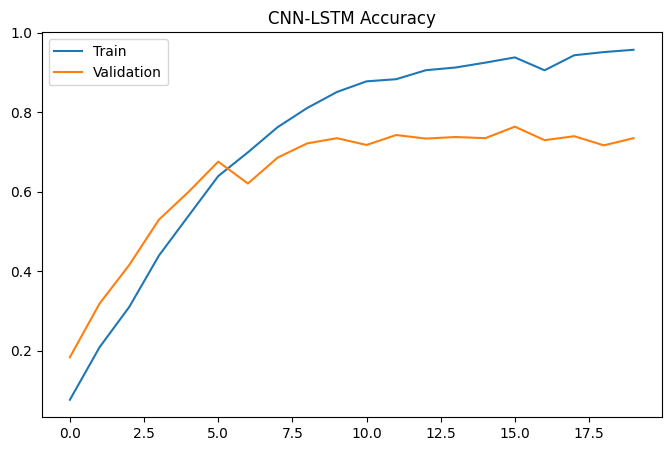

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train", "Validation"])
plt.title("CNN-LSTM Accuracy")
plt.show()